In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
# Dropout Layer 구현

def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1

    if dropout == 1:
        return torch.zeros_like(X)

    mask = (
        # X와 같은 shape의 난수 생성 후,
        # dropout 확률보다 큰 값만 True로 남기기
        torch.rand_like(X)
        > dropout
    ).float()

    return mask * X / (1.0 - dropout)

In [3]:
# Dropout Probability별 동작 확인

X = torch.arange(
    16,
    dtype=torch.float32,
).reshape(2, 8)

print(
    "dropout_p = 0\n",
    dropout_layer(X, 0),
)


print(
    "dropout_p = 0.5\n",
    dropout_layer(X, 0.5),
)

print(
    "dropout_p = 0.75\n",
    dropout_layer(X, 0.75),
)

print(
    "dropout_p = 1\n",
    dropout_layer(X, 1),
)

dropout_p = 0
 tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
dropout_p = 0.5
 tensor([[ 0.,  2.,  4.,  6.,  0.,  0., 12.,  0.],
        [ 0.,  0.,  0., 22., 24., 26., 28.,  0.]])
dropout_p = 0.75
 tensor([[ 0.,  0.,  0., 12.,  0., 20.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0., 52.,  0.,  0.]])
dropout_p = 1
 tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [ ]:
# Dropout MLP

class DropoutMLPScratch(d2l.Classifier):
    
    def __init__(
        self,
        num_outputs,
        num_hiddens_1,
        num_hiddens_2,
        dropout_1,
        dropout_2,
        lr,
    ):
        
        super().__init__()
        
        self.save_hyperparameters() 
        
        self.lin1 = nn.LazyLinear(
            num_hiddens_1 # 256
        )
        self.lin2 = nn.LazyLinear(
            num_hiddens_2 # 256
        )
        self.lin3 = nn.LazyLinear(
            num_outputs # 10
        )

        self.relu = nn.ReLU()
        
    def forward(self, X):
        # [B, 1, 28, 28] -> [B, 784]
        X = X.reshape(
            X.shape[0],
            -1,
        )
        
        # [B, 784] -> [B, 256]
        H1 = self.relu(
            self.lin1(X)
        )
        
        # dropout_1
        if self.training:
            H1 = dropout_layer(
                H1,
                self.dropout_1,
            )
        
        # [B, 256] -> [B, 256]
        H2 = self.relu(
            self.lin2(H1)
        )
        
        # dropout_2
        if self.training:
            H2 = dropout_layer(
                H2,
                self.dropout_2,
            )
        
        # [B, 256] → [B, 10]
        return self.lin3(H2)

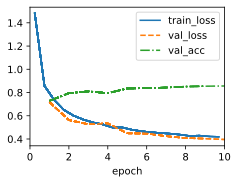

In [5]:
# Fashion-MNIST Training

hparams = {
    "num_outputs": 10,
    "num_hiddens_1": 256,
    "num_hiddens_2": 256,
    "dropout_1": 0.5,
    "dropout_2": 0.5,
    "lr": 0.1,
}

model = DropoutMLPScratch(**hparams)

data = d2l.FashionMNIST(
    batch_size=256,
)

trainer = d2l.Trainer(
    max_epochs=10,
)

trainer.fit(
    model,
    data,
)